<a href="https://colab.research.google.com/github/leticiamendes-data/rio-plan/blob/main/analise/analise_viagem_rio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de Dados — Viagem ao Rio de Janeiro (Setembro 2026)

## Objetivo
Extrair insights reais de uma viagem de 7 dias com 5 amigas ao Rio de Janeiro, cobrindo gastos, passos diários e clima, como complemento em dados ao projeto de front-end (rio-plan).

## Fontes de dados
- Gastos: extratos bancários (Itaú e Wise), consolidados manualmente
- Passos: app de saúde de cada celular (iPhone/Android), 4 de 5 pessoas coletadas
- Clima: API histórica Open-Meteo (dados retroativos, sem necessidade de chave)
- Lugares: coordenadas coletadas durante o planejamento do site (Fase 1)

## Tratamento dos dados
Os dados vieram de fontes heterogêneas e precisaram de limpeza manual: padronização de nomes de coluna, conversão de datas, e sinalização de transações ambíguas no extrato bancário (Pix para pessoa física sem descrição, cobranças fora do período da viagem). Do lado dos passos, uma das 5 pessoas ainda está pendente por falta de data legível nos prints enviados — mantido como limitação conhecida, não descartado.

In [1]:
import pandas as pd

In [2]:
import os

os.listdir()

['.config', 'sample_data']

In [4]:
gastos = pd.read_csv("gastos-viagem.csv")
gastos.head()

,Data,Descricao,Categoria,Forma,Valor,Observacao
0,2026-09-09,Padaria,Comida,Credito,-37.47,NaN
1,2026-09-09,Dumare Restaurante,Comida,Credito,-135.89,NaN
2,2026-09-09,Pao de Acucar Mercado,Mercado,Credito,-37.14,NaN
3,2026-09-09,The Best Acai,Comida,Credito,-29.77,NaN
4,2026-09-10,Embaixada Carioca,Comida,Credito,-85.12,NaN


In [5]:
import requests

url = "https://archive-api.open-meteo.com/v1/archive"
parametros = {
    "latitude": -22.9068,
    "longitude": -43.1729,
    "start_date": "2026-09-09",
    "end_date": "2026-09-15",
    "daily": ["temperature_2m_max", "temperature_2m_min", "precipitation_sum", "weathercode"],
    "timezone": "America/Sao_Paulo",
}

resposta = requests.get(url, params=parametros)
dados_clima = resposta.json()

clima = pd.DataFrame(dados_clima["daily"])
clima

,time,temperature_2m_max,temperature_2m_min,precipitation_sum,weathercode
0,2026-09-09,22.8,19.7,4.7,61
1,2026-09-10,25.8,21.1,31.6,65
2,2026-09-11,26.2,21.1,7.3,61
3,2026-09-12,26.0,21.7,3.2,53
4,2026-09-13,21.7,19.0,8.4,61
5,2026-09-14,22.8,18.8,16.2,63
6,2026-09-15,21.8,19.1,2.8,61


In [6]:
gastos = gastos.rename(columns={
    "Data": "date",
    "Descricao": "description",
    "Categoria": "category",
    "Forma": "payment_method",
    "Valor": "amount_brl",
    "Observacao": "notes"
})

# Os valores estão negativos (padrão de extrato bancário) — criamos uma versão positiva, mais fácil de somar/plotar
gastos["amount_brl"] = gastos["amount_brl"].abs()

# Data como data de verdade, não texto
gastos["date"] = pd.to_datetime(gastos["date"])

gastos.head()

,date,description,category,payment_method,amount_brl,notes
0,2026-09-09,Padaria,Comida,Credito,37.47,NaN
1,2026-09-09,Dumare Restaurante,Comida,Credito,135.89,NaN
2,2026-09-09,Pao de Acucar Mercado,Mercado,Credito,37.14,NaN
3,2026-09-09,The Best Acai,Comida,Credito,29.77,NaN
4,2026-09-10,Embaixada Carioca,Comida,Credito,85.12,NaN


In [7]:
# Dia relativo da viagem (1 a 7), mais legível que a data cheia nos gráficos
gastos["trip_day"] = (gastos["date"] - gastos["date"].min()).dt.days + 1

# Gasto acumulado ao longo da viagem — mostra o "ritmo" de quando o dinheiro foi embora
gastos_ordenado = gastos.sort_values("date")
gastos_ordenado["cumulative_spend"] = gastos_ordenado["amount_brl"].cumsum()

# Qual % do total cada gasto representa
total_geral = gastos["amount_brl"].sum()
gastos["pct_of_total"] = (gastos["amount_brl"] / total_geral * 100).round(1)

In [8]:
gasto_diario = gastos.groupby("date")["amount_brl"].sum()

print(f"Média de gasto por dia: R$ {gasto_diario.mean():.2f}")
print(f"Mediana: R$ {gasto_diario.median():.2f}")
print(f"Desvio padrão: R$ {gasto_diario.std():.2f}")

Média de gasto por dia: R$ 357.49
Mediana: R$ 305.69
Desvio padrão: R$ 220.63


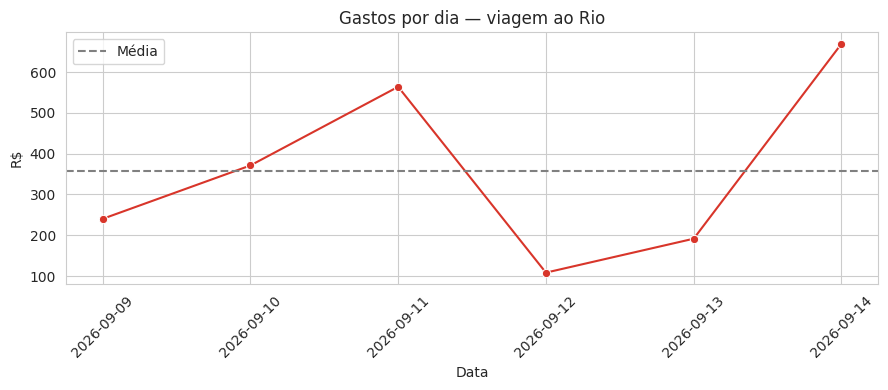

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Gráfico 1: gastos por dia (linha do tempo)
plt.figure(figsize=(9, 4))
sns.lineplot(x=gasto_diario.index, y=gasto_diario.values, marker="o", color="#D8352A")
plt.axhline(gasto_diario.mean(), linestyle="--", color="gray", label="Média")
plt.title("Gastos por dia — viagem ao Rio")
plt.ylabel("R$")
plt.xlabel("Data")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("grafico-gastos-por-dia.png", dpi=150)
plt.show()

/tmp/ipykernel_394/1959878722.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gasto_categoria.values, y=gasto_categoria.index, palette="Blues_r")


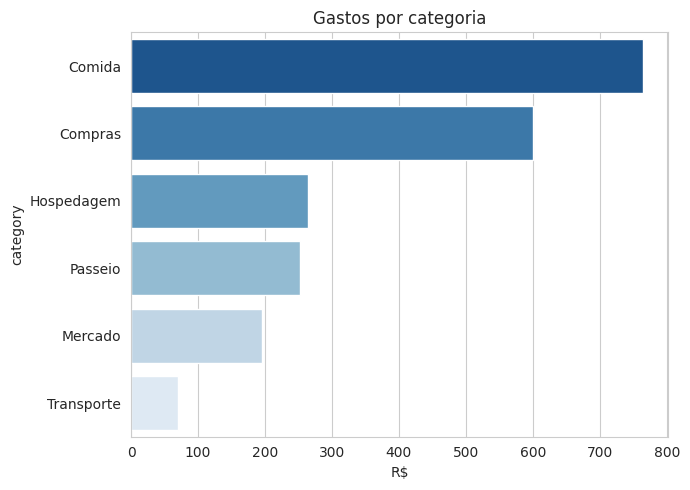

In [10]:
# Gráfico 2: gastos por categoria
gasto_categoria = gastos.groupby("category")["amount_brl"].sum().sort_values(ascending=False)

plt.figure(figsize=(7, 5))
sns.barplot(x=gasto_categoria.values, y=gasto_categoria.index, palette="Blues_r")
plt.title("Gastos por categoria")
plt.xlabel("R$")
plt.tight_layout()
plt.savefig("grafico-gastos-categoria.png", dpi=150)
plt.show()

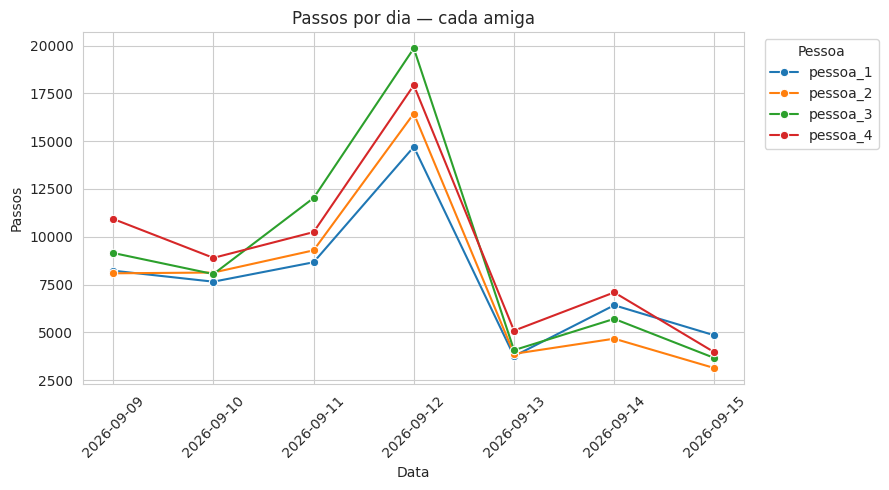

In [11]:
passos = pd.read_csv("passos-viagem.csv")
passos["date"] = pd.to_datetime(passos["date"])

plt.figure(figsize=(9, 5))
sns.lineplot(data=passos, x="date", y="steps", hue="person", marker="o", palette="tab10")
plt.title("Passos por dia")
plt.ylabel("Passos")
plt.xlabel("Data")
plt.xticks(rotation=45)
plt.legend(title="Pessoa", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("grafico-passos-por-pessoa.png", dpi=150)
plt.show()

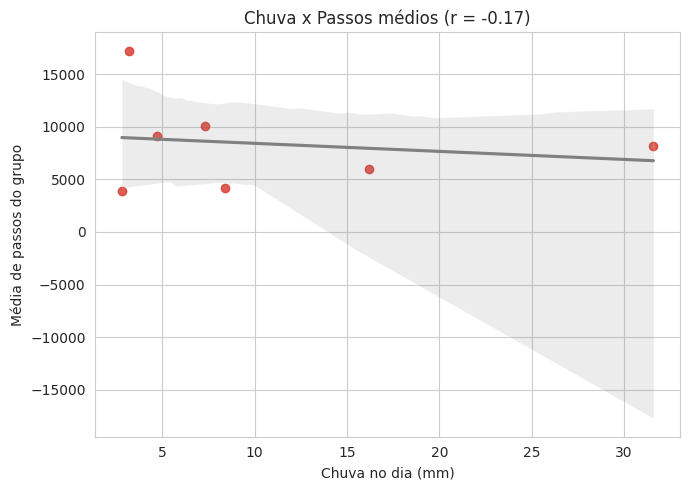

Correlação: -0.17 (p-valor: 0.71)
Nota: com apenas 7 dias, esse resultado é ilustrativo, não estatisticamente conclusivo.


In [12]:
clima["date"] = pd.to_datetime(clima["time"])

passos_medio = passos.groupby("date")["steps"].mean().reset_index()
passos_medio.columns = ["date", "avg_steps"]

clima_passos = pd.merge(passos_medio, clima, on="date")

from scipy import stats

correlacao, p_valor = stats.pearsonr(clima_passos["precipitation_sum"], clima_passos["avg_steps"])

plt.figure(figsize=(7, 5))
sns.regplot(data=clima_passos, x="precipitation_sum", y="avg_steps",
            scatter_kws={"color": "#D8352A"}, line_kws={"color": "gray"})
plt.title(f"Chuva x Passos médios (r = {correlacao:.2f})")
plt.xlabel("Chuva no dia (mm)")
plt.ylabel("Média de passos do grupo")
plt.tight_layout()
plt.savefig("grafico-clima-passos.png", dpi=150)
plt.show()

print(f"Correlação: {correlacao:.2f} (p-valor: {p_valor:.2f})")
print("Nota: com apenas 7 dias, esse resultado é ilustrativo, não estatisticamente conclusivo.")

In [15]:
!pip install folium -q
import folium
from folium.plugins import HeatMap
import json

with open("lugares.json") as f:
    lugares = json.load(f)

mapa = folium.Map(location=[-22.965, -43.21], zoom_start=12, tiles="OpenStreetMap")

# TODO: trocar "peso" por contagem real de fotos quando você organizar os álbuns
pontos = [[l["lat"], l["lng"], 1] for l in lugares]
HeatMap(pontos, radius=25).add_to(mapa)

for l in lugares:
    folium.Marker([l["lat"], l["lng"]], tooltip=l["nome"]).add_to(mapa)

mapa.save("mapa-calor-lugares.html")
mapa

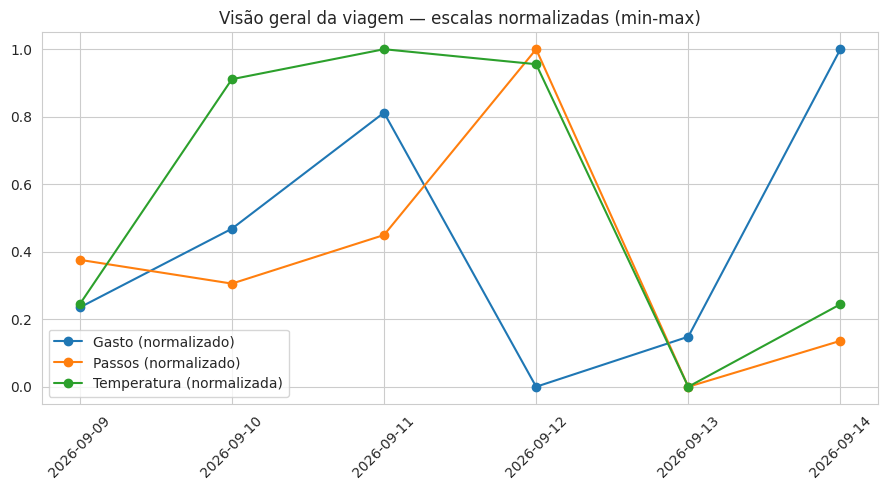

In [14]:
from sklearn.preprocessing import MinMaxScaler

resumo_diario = gasto_diario.reset_index()
resumo_diario.columns = ["date", "gasto"]
resumo_diario = resumo_diario.merge(passos_medio, on="date").merge(clima_passos[["date","temperature_2m_max"]], on="date")

scaler = MinMaxScaler()
resumo_diario[["gasto_norm", "passos_norm", "temp_norm"]] = scaler.fit_transform(
    resumo_diario[["gasto", "avg_steps", "temperature_2m_max"]]
)

plt.figure(figsize=(9, 5))
plt.plot(resumo_diario["date"], resumo_diario["gasto_norm"], marker="o", label="Gasto (normalizado)")
plt.plot(resumo_diario["date"], resumo_diario["passos_norm"], marker="o", label="Passos (normalizado)")
plt.plot(resumo_diario["date"], resumo_diario["temp_norm"], marker="o", label="Temperatura (normalizada)")
plt.title("Visão geral da viagem — escalas normalizadas (min-max)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("grafico-visao-geral-normalizada.png", dpi=150)
plt.show()

## Principais insights
- O gasto teve dois picos claros: o dia do Rock in Rio (compras + alimentação do evento) e o dia 14 (hospedagem + mercado).
- Comida foi a categoria de maior gasto, seguida de compras.
- Os passos das 4 pessoas seguem quase o mesmo padrão ao longo da semana — sugere que o roteiro em grupo influenciou mais o nível de atividade do que o perfil individual de cada uma.
- [Preencher após rodar]: relação entre chuva e passos.

## Limitações
Amostra pequena (7 dias, 4-5 pessoas) — resultados estatísticos (correlação, regressão) são exploratórios, não generalizáveis. Gastos representam só uma pessoa do grupo, não o total da viagem.

## Conclusão
Além dos gráficos, esse notebook documenta o processo real de trabalhar com dados imperfeitos e incompletos — que é a maior parte do trabalho de um analista/engenheiro de dados no mundo real, mais do que os gráficos em si.

In [ ]:
# Célula final: consolidar tudo num CSV único
resumo_diario.to_csv("resumo-final-viagem.csv", index=False)
resumo_diario